In [7]:
#import libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset
import datetime as dt

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


C:\Users\Charlie\AppData\Local\Temp\ipykernel_1996\2783347909.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_DA_UK['job_posted_month_no'] = df_DA_UK['job_posted_date'].dt.month


<Axes: xlabel='job_posted_month_no'>

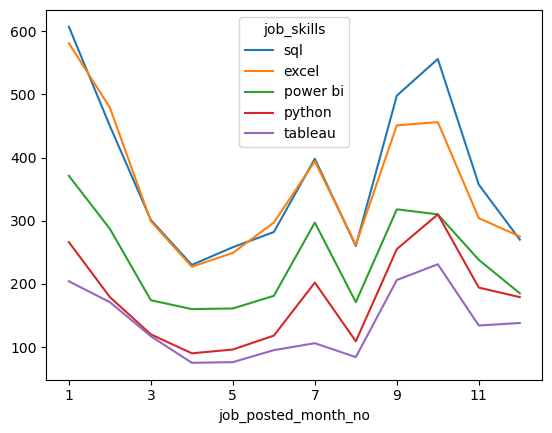

In [48]:
df_DA_UK = df[(df['job_country'] == 'United Kingdom') & (df['job_title_short'] == 'Data Analyst')]
df_DA_UK['job_posted_month_no'] = df_DA_UK['job_posted_date'].dt.month
df_DA_UK_explode = df_DA_UK.explode('job_skills')
df_DA_UK_explode
df_DA_UK_pivot = df_DA_UK_explode.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)
df_DA_UK_pivot.loc['Total'] = df_DA_UK_pivot.sum()
df_DA_UK_pivot = df_DA_UK_pivot.sort_values(by = 'Total', axis = 'columns', ascending=False)

df_DA_UK_pivot.drop(labels = 'Total', axis = 0, inplace=True)

df_DA_UK_pivot.iloc[:,:5].plot(kind='line')